# Two-module RNN (task-routed input): training and basic analysis

This notebook runs the **training pipeline** for the two-module RNN condition with **task-routed (separated) input** (A→module 1, B→module 2 via feature_probe; analogous to `02_run_simulations.py`), then runs **Holton-style** transfer/loss/PCA analyses and **dynspec-inspired** checks to verify functionality.

Run cells **one after another**: first training, then load and analyse.

## 1. Setup and paths

In [1]:
import sys
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project root (parent of a1b2)
project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

import importlib
from a1b2.data.basic_funcs import set_seed
from a1b2.training.simulation import run_simulation
from a1b2.utils.run_config import build_run_id
from a1b2.analysis import transfer_interference as ann
from a1b2.analysis import stats
from a1b2.utils import figure_utils
from a1b2.utils.figure_settings import schedule_colours, condition_order, task_colours
# Reload models so code changes (e.g. community.py cell_types_dict) are picked up without kernel restart
import a1b2.models.community
import a1b2.models.two_module_rnn
importlib.reload(a1b2.models.community)
importlib.reload(a1b2.models.two_module_rnn)

<module 'a1b2.models.two_module_rnn' from '/home/kathrin/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/a1b2/models/two_module_rnn.py'>

## 2. Run training (two-module RNN, task-routed input)

Uses the same pipeline as `scripts/02_run_simulations.py`: load condition from `experiments.json`, build run_id, run simulation, save `.npz` per participant to `data/simulations/<run_id>/`.

In [2]:
CONDITION_NAME = "two_module_rnn_50_task_routed"

def load_settings(config_path):
    with open(config_path, "r") as f:
        return json.load(f)

set_seed(2024)
data_folder = project_root / "data"
config_path = project_root / "a1b2" / "models" / "experiments.json"
settings = load_settings(config_path)
condition = next((c for c in settings["conditions"] if c["name"] == CONDITION_NAME), None)
if condition is None:
    raise ValueError(f"Condition '{CONDITION_NAME}' not found in experiments.json")

df = ann.load_participant_data(str(data_folder))
participants = df["participant"].unique()
task_parameters = ann.setup_task_parameters()

dim_input = task_parameters["nStim_perTask"] * 2
arch = condition.get("arch", "ffn")
if arch in ("two_module_rnn", "single_module_rnn"):
    n_modules = condition.get("n_modules", 2 if arch == "two_module_rnn" else 1)
    dim_hidden = n_modules * condition.get("dim_hidden", 50)
else:
    dim_hidden = condition["dim_hidden"]
dim_output = 4
network_params = [dim_input, dim_hidden, dim_output]

training_params = [
    list(participants),
    settings["n_phase"],
    settings["n_epochs"],
    settings["n_epochs"] * (task_parameters["nStim_perTask"] * 2) * 10,
    settings["shuffle"],
    settings["batch_size"],
    condition.get("gamma", 0.01),
    settings["learning_rate"],
]

run_id = build_run_id(condition)
sim_folder = data_folder / "simulations" / run_id
sim_folder.mkdir(parents=True, exist_ok=True)

print(f"Condition: {CONDITION_NAME}, run_id: {run_id}")
print(f"Arch: {arch}, participants: {len(participants)}")
print(f"Saving to: {sim_folder}")

Condition: two_module_rnn_50_task_routed, run_id: two_module_rnn_50_task_routed_nb1_task_routed_sp1_ci_cr_RNN
Arch: two_module_rnn, participants: 305
Saving to: /home/kathrin/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/two_module_rnn_50_task_routed_nb1_task_routed_sp1_ci_cr_RNN


In [ ]:
# Run simulation (one participant after another; saves sim_<participant>.npz)
run_simulation(
    training_params,
    network_params,
    task_parameters,
    df,
    do_test=1,
    dosave=1,
    sim_folder=str(sim_folder),
    arch=arch,
    condition=condition if arch in ("two_module_rnn", "single_module_rnn") else None,
)
print("Training finished.")

## 3. Load results and verify

In [3]:
ann_folder = sim_folder
ann_data = ann.load_ann_data(str(ann_folder))

# Quick verification: expected keys per condition
for cond in ["same", "near", "far"]:
    n = len(ann_data[cond])
    print(f"{cond}: {n} participants")
    if n > 0:
        keys = list(ann_data[cond][0].keys())
        assert "predictions" in keys and "hiddens_post_phase_0" in keys and "hiddens_post_phase_1" in keys
        print(f"  Keys: {keys}")
print("Load and structure OK.")

same: 103 participants
  Keys: ['participant', 'predictions', 'labels', 'accuracy', 'losses', 'test_stim', 'hiddens_post_phase_0', 'hiddens_post_phase_1']
near: 101 participants
  Keys: ['participant', 'predictions', 'labels', 'accuracy', 'losses', 'test_stim', 'hiddens_post_phase_0', 'hiddens_post_phase_1']
far: 101 participants
  Keys: ['participant', 'predictions', 'labels', 'accuracy', 'losses', 'test_stim', 'hiddens_post_phase_0', 'hiddens_post_phase_1']
Load and structure OK.


## 4. Holton-style analyses (transfer-interference)

Transfer metrics, training loss, PCA components, principal angles, and standard plots from `figure_utils`.

In [4]:
# Transfer metrics
ann_transfer = ann.compute_transfer_anns(ann_data)
ann_stats = stats.compare_transfer(ann_transfer, metric_col="error_diff")
print("Transfer stats (error_diff):", ann_stats)

# Training loss (for loss curves)
loss_results = ann.analyze_training_loss(ann_data)
print("Loss analysis done.")

Transfer stats (error_diff): {'descriptives': {'same': {'mean': -0.392, 'sem': 0.01}, 'near': {'mean': -0.388, 'sem': 0.01}, 'far': {'mean': -0.394, 'sem': 0.01}}, 'anova': {'f_stat': 0.105, 'df_between': 2, 'df_within': 302, 'eta_squared': 0.001, 'p_value': 0.9}, 'posthoc': {'same_vs_near': {'t_stat': -0.306, 'df': 202, 'cohens_d': -0.043, 'p_value': 0.62}, 'same_vs_far': {'t_stat': 0.152, 'df': 202, 'cohens_d': 0.021, 'p_value': 0.44}, 'near_vs_far': {'t_stat': 0.446, 'df': 200, 'cohens_d': 0.063, 'p_value': 0.328}}}
Loss analysis done.


In [5]:
# PCA components and principal angles
pca_df = ann.compute_pca_components(ann_data, variance_threshold=0.99)
angles_df = ann.get_principal_angles(ann_data)
print("PCA components (n_pca):")
print(pca_df.head())
print("Principal angles:")
print(angles_df.head())

PCA components (n_pca):
             participant condition    task  n_pca
0  sim_study2_same_sub10      same  post A     11
1  sim_study2_same_sub10      same  post B     11
2  sim_study1_same_sub41      same  post A     11
3  sim_study1_same_sub41      same  post B     11
4  sim_study2_same_sub61      same  post A     11
Principal angles:
             participant condition  principal_angle_between
0  sim_study2_same_sub10      same                44.160618
1  sim_study1_same_sub41      same                55.999516
2  sim_study2_same_sub61      same                50.523548
3  sim_study2_same_sub12      same                50.874744
4   sim_study1_same_sub1      same                48.959034


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

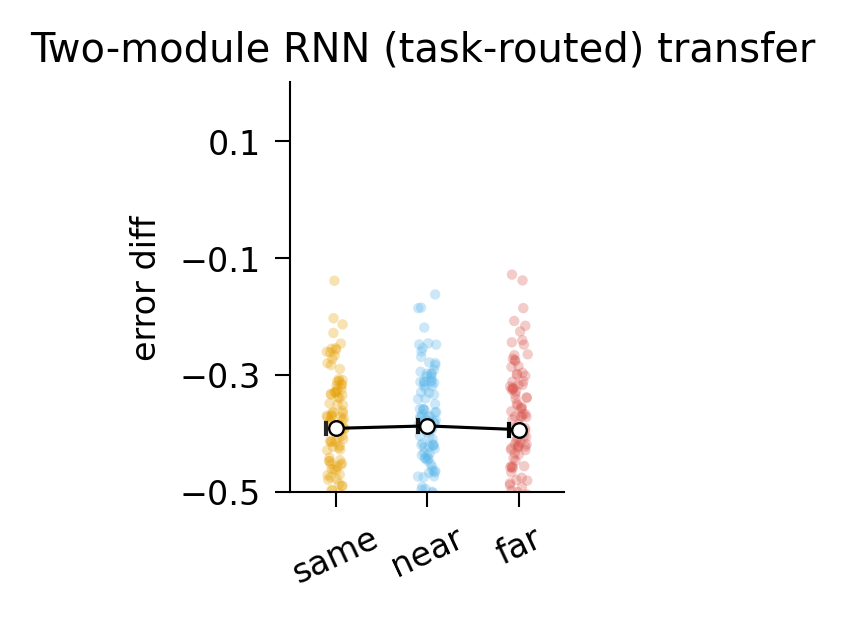

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

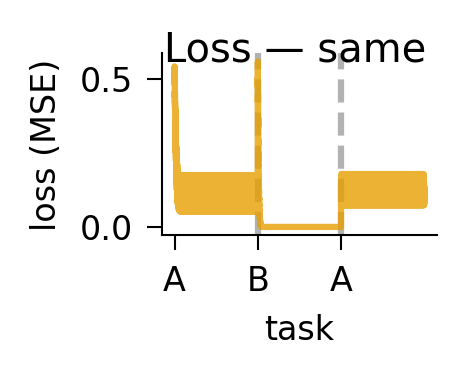

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

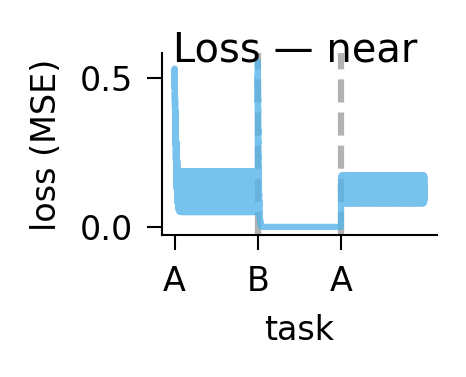

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

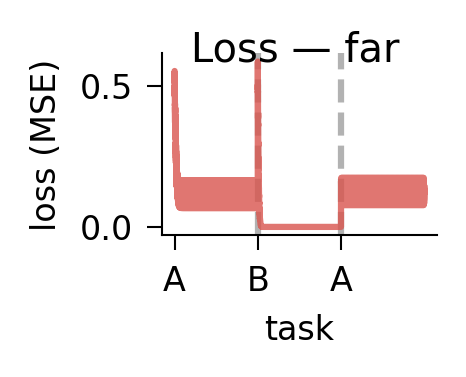

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

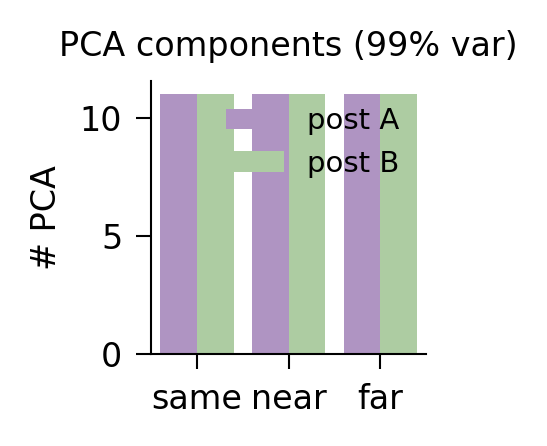

In [6]:
# Plots: transfer, loss curves, PCA
p_values = [ann_stats["posthoc"][k]["p_value"] for k in ["same_vs_near", "same_vs_far", "near_vs_far"]]

fig1, _ = figure_utils.plot_transfer(
    ann_transfer, "error_diff", condition_order, "error diff", [-0.5, 2.5], [-0.5, 0.2], np.arange(-0.5, 0.21, 0.2), schedule_colours, p_values
)
fig1.suptitle("Two-module RNN (task-routed) transfer")
plt.show()

for sched in ["same", "near", "far"]:
    if len(ann_data[sched]) > 0:
        fig2, _ = figure_utils.plot_loss_curves(ann_data, sched, schedule_colours, n_epochs=settings["n_epochs"])
        fig2.suptitle(f"Loss — {sched}")
        plt.show()

fig3, ax3 = figure_utils.plot_pca_components(pca_df, task_colours)
ax3.set_title("PCA components (99% var)")
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

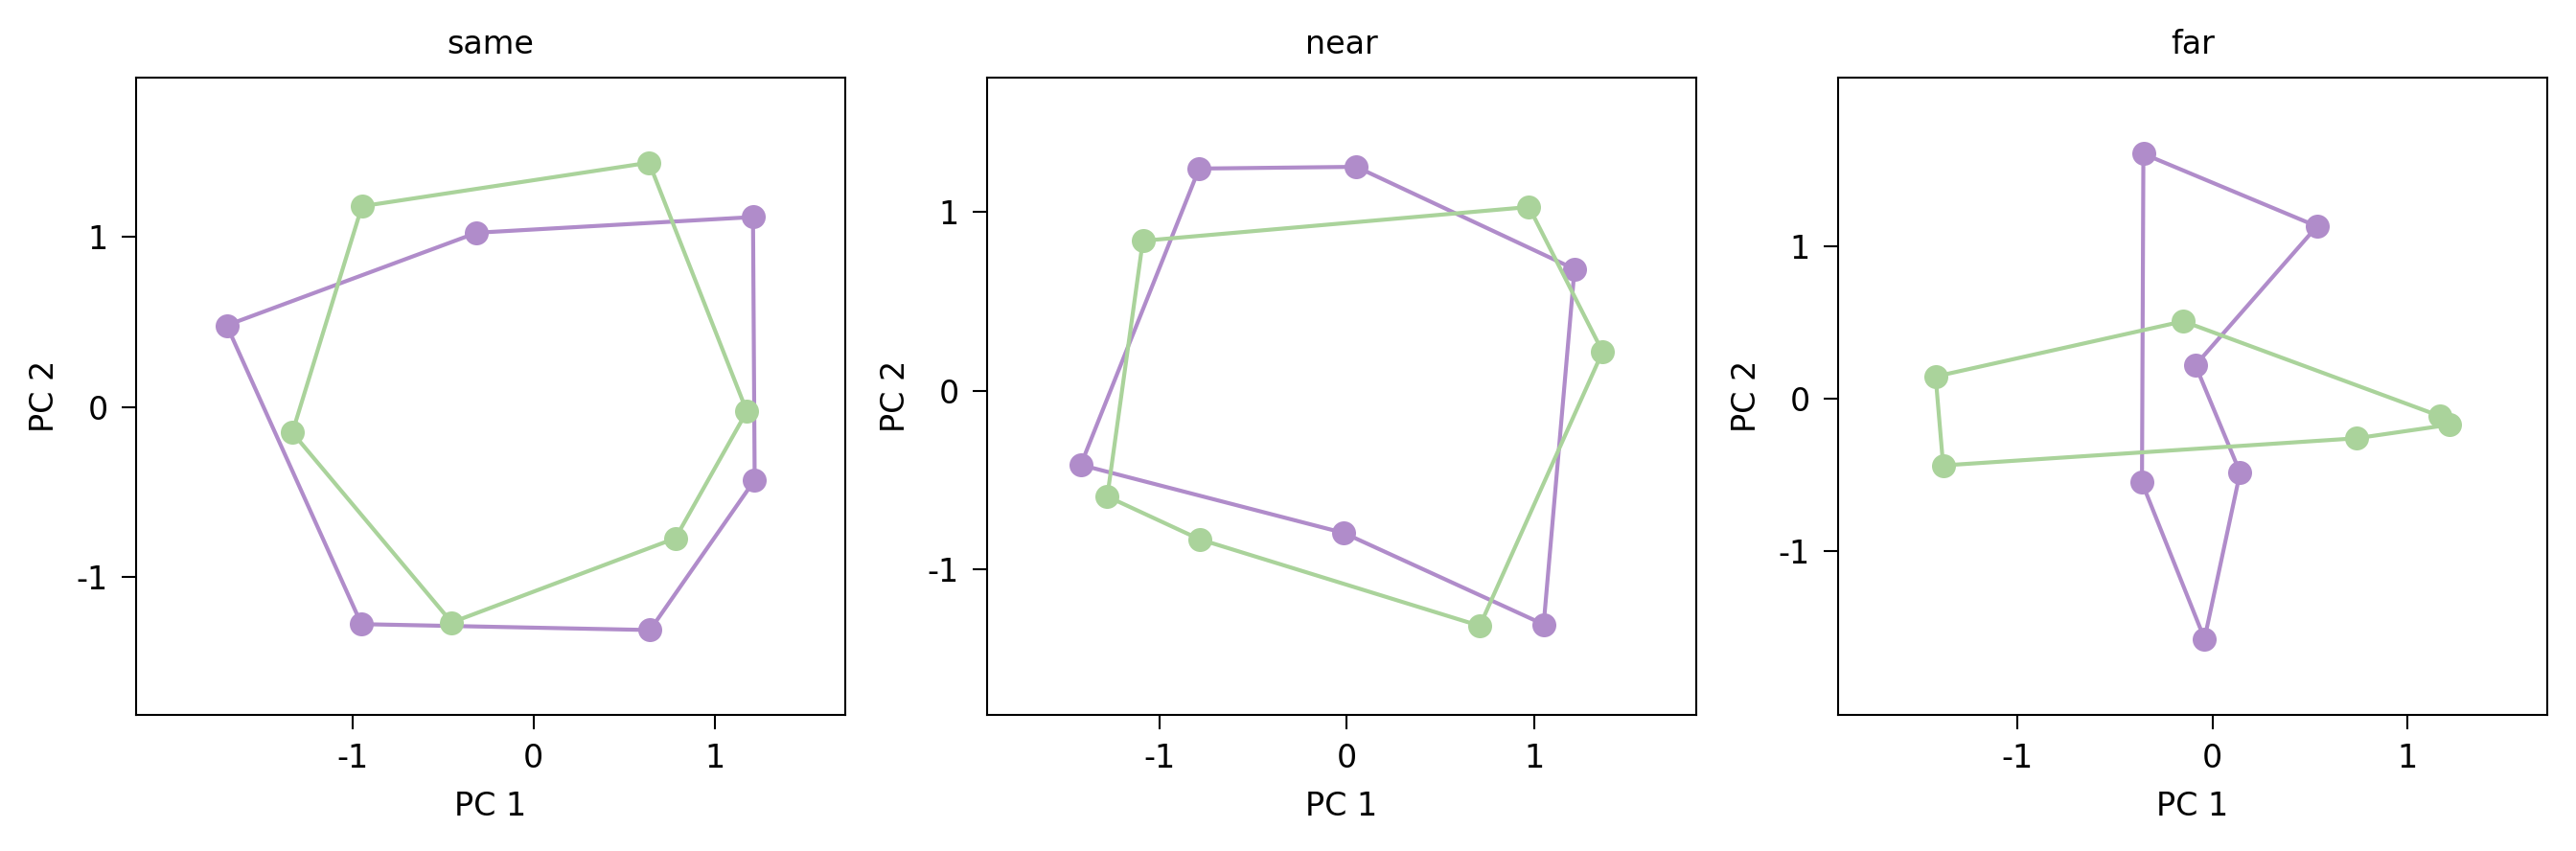

In [7]:
# Optional: 2D PCA of hidden states (one participant per condition)
from a1b2.utils.figure_utils import get_axis_limits, plot_split_stim

fig4, axes = plt.subplots(1, 3, figsize=(9, 3))
all_lims = None
for ax, (sched, s_idx) in zip(axes, [("same", 0), ("near", 1), ("far", 2)]):
    if len(ann_data[sched]) == 0:
        continue
    hiddens = ann_data[sched][0]["hiddens_post_phase_1"]  # (n_conditions, n_stim, dim)
    if hiddens.ndim == 3:
        h = hiddens[0, :, :]  # first condition block
    else:
        h = hiddens
    pca, transformed = ann.prepare_pca_single_task(h)
    plot_split_stim(ax, transformed, task_colours, get_axis_limits(transformed))
    ax.set_title(sched)
plt.tight_layout()
plt.show()

## 5. Dynspec-inspired analyses

**Applicability note:** For a **two-module RNN** on the A1–B–A2 **regression** task we use **per-module activity magnitude** (L2 norm from `hiddens_per_module`); with task-routed input, modules receive different inputs (A vs B) so magnitude may differ by module.

Below: per-module magnitude from `hiddens_per_module` (two modules); otherwise fallback from full hiddens.

In [8]:
# Check for optional RNN-specific keys (per-module hiddens, trajectory)
sample = ann_data["same"][0] if len(ann_data["same"]) > 0 else None
has_per_module = sample is not None and "hiddens_per_module" in sample
has_trajectory = sample is not None and "hiddens_post_phase_0_trajectory" in sample
print(f"hiddens_per_module present: {has_per_module}")
print(f"trajectory present: {has_trajectory}")

hiddens_per_module present: False
trajectory present: False


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

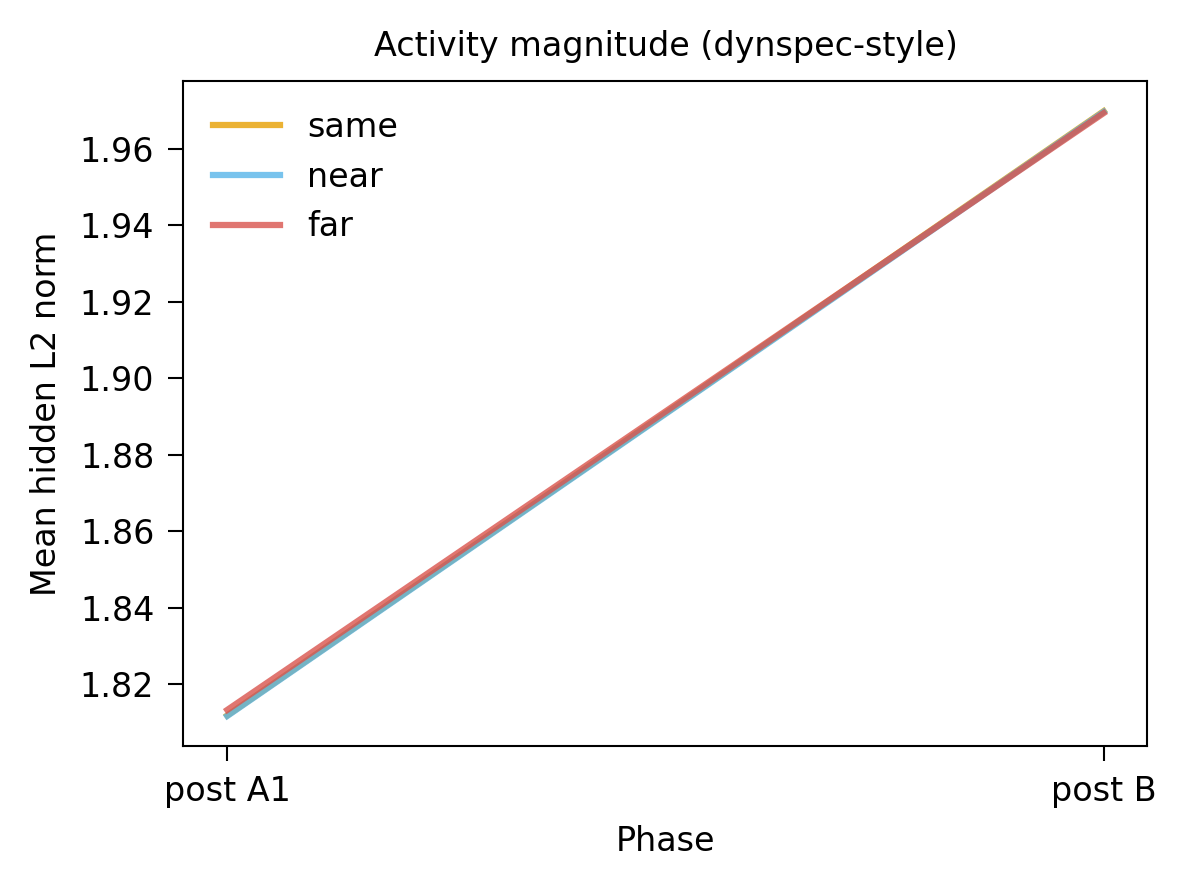

In [9]:
# Activity magnitude (dynspec-style): L2 norm of hidden activity
# If hiddens_per_module: (n_phase, n_trials, n_modules, dim) -> mean L2 per module over trials
# Else: use hiddens_post_phase_0/1 (e.g. mean over stimuli)
def activity_magnitude_per_module(participant_data):
    if "hiddens_per_module" in participant_data:
        H = participant_data["hiddens_per_module"]  # (n_phase, n_trials, n_mod, dim)
        n_phase, n_trials, n_mod, dim = H.shape
        norms = np.linalg.norm(H, axis=3)  # (n_phase, n_trials, n_mod)
        return np.nanmean(norms, axis=1)  # (n_phase, n_mod)
    # Fallback: one "module" from post-phase hiddens (mean over stimuli)
    out = []
    for ph in [0, 1]:
        key = f"hiddens_post_phase_{ph}"
        if key not in participant_data:
            continue
        h = participant_data[key]  # (n_cond, n_stim, dim) or (n_stim, dim)
        h_flat = h.reshape(-1, h.shape[-1])
        out.append(np.nanmean(np.linalg.norm(h_flat, axis=1)))
    return np.array(out).reshape(-1, 1) if out else None

magnitudes = []
for sched in ["same", "near", "far"]:
    for i in range(len(ann_data[sched])):
        mag = activity_magnitude_per_module(ann_data[sched][i])
        if mag is not None:
            magnitudes.append({"condition": sched, "magnitude": mag})

if magnitudes:
    # Plot mean magnitude per phase
    fig5, ax5 = plt.subplots(figsize=(4, 3))
    phase_labels = ["post A1", "post B", "post A2"]
    n_phase = magnitudes[0]["magnitude"].shape[0]
    for s_idx, sched in enumerate(["same", "near", "far"]):
        m = [x["magnitude"] for x in magnitudes if x["condition"] == sched]
        if not m:
            continue
        mean_mag = np.nanmean(np.stack(m), axis=0)
        _n_phase, n_mod = mean_mag.shape
        x = np.arange(_n_phase)
        for mod in range(n_mod):
            ax5.plot(x, mean_mag[:, mod], color=schedule_colours[s_idx], label=sched if mod == 0 else None, alpha=0.8)
    ax5.set_xticks(np.arange(n_phase))
    ax5.set_xticklabels(phase_labels[:n_phase])
    ax5.set_ylabel("Mean hidden L2 norm")
    ax5.set_xlabel("Phase")
    ax5.legend()
    ax5.set_title("Activity magnitude (dynspec-style)")
    plt.tight_layout()
    plt.show()
else:
    print("No magnitude data (missing hiddens_post_phase_* or hiddens_per_module).")

## 6. Summary

- **Training:** Two-module RNN (task-routed input) trained with the same pipeline as `02_run_simulations.py`; results in `data/simulations/<run_id>/`.
- **Holton:** Transfer, loss curves, PCA components, principal angles, and transfer/PCA plots confirm behaviour.
- **Dynspec:** Per-module activity magnitude (two modules) from `hiddens_per_module`; trajectory if present.